# 04 — DOORS / EMBLAS / L2A validation bridge
Локальный воспроизводимый анализ; новых независимых labels ещё нет.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
while not (ROOT/'reports/validation_bridge').exists(): ROOT=ROOT.parent
OUT=ROOT/'reports/validation_bridge'
display(Markdown((OUT/'summary.md').read_text()))

# Продолжение валидации: EMBLAS / DOORS / L2A — 26.09.2026

**Готовы оптические данные DOORS, диагностика двух пар rhorc/L2A и 12 снимков для независимой разметки. Новых готовых событий T3: 0. Улучшение скора модели в этом шаге не заявляется.**

## Полевые данные и новые источники

| Набор | Что собрано | Что ещё нужно |
|---|---|---|
| EMBLAS 2017/2019 | 302 сессии, площадь и counts, 40 нулей (ранее подготовлены) | Координаты/треки по Session ID, timezone/UTC |
| DOORS июнь 2024 | Два DOI сверены: те же 33 даты, midpoints и плотности | UTC, endpoints/track, ширина, площадь, counts |
| DOORS TriOS | 27 спектров × 451 длина волны, координаты и UTC | Проверка водной атмосферной коррекции, SRF и протокола matchup |
| DOORS MicroPro / гидрология | 11 агрегированных AOP; 27 строк CHL/TSM/Secchi; исходный AOT | Межприборная проверка; отдельные единицы и протоколы |
| Румыния, июль 2024 | Новая таблица 8 трансект: даты, длины, суммарная площадь 0.7231 км² | Числовая геометрия, UTC, counts/density по каждой трансекте |

Источник TriOS: [Zenodo 15778382](https://zenodo.org/records/15778382). Rrs имеет единицу sr⁻¹, это не rhorc и не L2A BOA reflectance. Отрицательных спектральных значений: 0, пропусков: 0; значения сохранены без обрезания. Сравнение абсолютной точности атмосферной коррекции по ним ещё не выполнено.

Спутниковый поиск по точному UTC: 12 подходящих пар тайлов для **6 из 27 измерений**, по одной основной паре на измерение сохранено отдельно. Условие — тот же календарный день, |Δt| ≤3 ч, все 3×3 пикселя SCL water и без nodata. Остальные причины отказа сохранены в таблице. Это кандидаты для оптического matchup: нужны проверка неоднородности, glint/adjacency, SRF и водный продукт. Маска SCL не подтверждает отсутствие мусора.

В обоих litter XLSX у T33 перепутаны latitude/longitude. В существующей базе исправление уже было документировано; исходник сохранён без переписывания. Время водных станций в litter-наблюдения не перенесено. В D4.5 обнаружены точные сетевые треки **микропластика**, но они не заменяют визуальные T1–T33. [Аудит и источники](search_audit.md), [готовые запросы владельцам](owner_requests.md). Сообщения не отправлялись.

## Одни и те же участки в rhorc и L2A

Из четырёх заранее выбранных MARIDA кропов два сопоставлены по уникальному tile/date/footprint. Для двух других в проверенной коллекции C1 совпадений нет; это не доказательство отсутствия снимков в других архивах. У исходного MARIDA нет product ID, поэтому идентичность исходной обработки/субсцены полностью не восстановлена.

Обе пары приведены к исходной сетке: 11 каналов, 10 м, nearest-neighbour. У C1 применены asset scale=0.0001 и offset=−0.1, nodata исключены. Сравниваются 120 размеченных пикселей, из них 32 debris. RF и порог 0.6310449457633717 заморожены.

| Кроп / исходный split | rhorc F1 | L2A F1 | Debris: TP/FN на L2A |
|---|---:|---:|---:|
| 22-12-20_18QYF_0 / test, 114 пикселей | 1.000 | 0.727 | 16 / 12 |
| 24-4-19_36JUN_0 / train, 6 пикселей | 1.000 | 0.667 | 2 / 2 |

Объединённый F1 L2A = 0.720; 14 из 32 положительных пикселей пропущены. **Это stress-test, не независимая оценка качества**: один кроп из train, соседние пиксели зависимы, всего две сцены; pooled F1 нельзя выдавать за test score. Общий участок 36JUN содержит облака; фильтр общей выборки здесь — валидность/существующая разметка, не чистая вода. Для анализа отдельно сохранены статистики только SCL water. Продукты физически различаются, поэтому спектральная разность не является ошибкой относительно наземной истины.

Вывод для следующего эксперимента: расширить парные сцены, затем обучать и валидировать вариант на целевом продукте либо проверять водную коррекцию. Эти четыре кропа не использовать для подбора преобразования или порога.

## Независимая разметка Чёрного моря

12 кропов 256×256×11 за июнь/сентябрь 2025, по два для Новороссийска, Сочи, Батуми, Синопа, Бургаса, Констанцы. **Разметки пока нет:** все labels=0/ignore, не negative; 786432 неизвестных пикселя. Для каждого подготовлены два независимых комплекта review.json / labels.tif / annotations.geojson. Все reserved_holdout, training_allowed=False, предсказания не вычислялись.

Выбор фиксирован по времени/качеству: первый подходящий снимок в окне, tile cloud ≤20%, локальные cloud/shadow ≤10%, water ≥60%, без nodata во всех каналах. Отказов из-за спектральных пропусков при годной SCL: 2. Набор смещён к прибрежным, ясным, водным сценам; не представляет всё Чёрное море и все погодные условия. Даты 2025 отделяют его от опубликованного временного покрытия обучающих наборов; это не гарантирует географическую независимость MADOS с неполными метаданными.

[Галерея для разметки](review_gallery.html) · [инструкция](review_instructions.md) · [реестр](tables/blacksea_holdout_registry.csv). До двух независимых проверок, разрешения разногласий и аудита доказательств score не рассчитывать. Детекция пикселей не переводится в items/km² без отдельной калибровки по полевым полосам.

## Что сильнее всего поможет модели дальше

1. Авторский экспорт EMBLAS/DOORS: UTC + реальные полосы/треки. Это исправит пространственно-временную связь цели со снимком.
2. Независимые подтверждённые положительные объекты и трудные отрицательные примеры Чёрного моря: пена, кильватер, суда, природные скопления, мутная вода. Текущий пакет готов к такому обзору, но 12 случайно выбранных кропов могут не содержать ни одного подтверждаемого мусорного объекта.
3. Больше одинаковых сцен L2A/rhorc и водной коррекции, с географически/временно разделённой валидацией. Найденные TriOS/AOP позволят проверять радиометрию; score мусора ими напрямую не измеряется.
4. Отдельный обучающий набор региона, затем замороженный тест на зарезервированных сценах. Результат этого теста не использовать для выбора порога или следующей версии модели.

Воспроизведение: [README](../../ml/validation_bridge/README.md). Контрольные суммы и версии: provenance.json, tables/source_manifest.csv, inputs_hashes.csv, imagery_hashes.csv. Существующая case-таблица и модели не изменены.


,patch_id,original_split,product,threshold,tp,fp,fn,tn,precision,recall,f1,iou,false_positive_rate
0,22-12-20_18QYF_0,test,rhorc,0.631045,28,0,0,86,1.0,1.000000,1.000000,1.000000,0.0
1,22-12-20_18QYF_0,test,L2A_stress_only,0.631045,16,0,12,86,1.0,0.571429,0.727273,0.571429,0.0
2,24-4-19_36JUN_0,train,rhorc,0.631045,4,0,0,2,1.0,1.000000,1.000000,1.000000,0.0
3,24-4-19_36JUN_0,train,L2A_stress_only,0.631045,2,0,2,2,1.0,0.500000,0.666667,0.500000,0.0


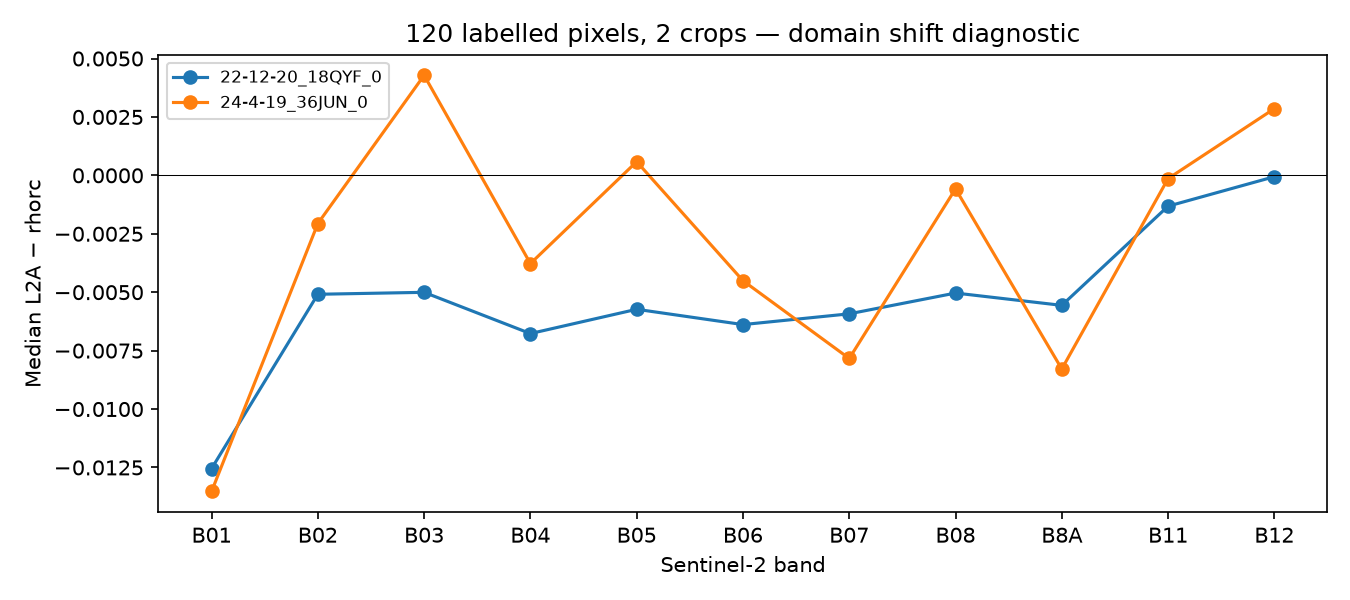

In [2]:
display(pd.read_csv(OUT/'tables/radiometry_stress_metrics.csv'))
display(Image(filename=str(OUT/'figures/radiometry_shift.png')))

,record_id,station,date,stac_id,time_difference_hours,field_datetime_utc,satellite_datetime,accepted,reason,target_type,nodata_fraction,cloud_fraction,water_fraction,selection_rule
0,DOORS3:TriOS:1,BS066,2024-06-02,S2A_T35TQJ_20240602T084613_L2A,0.671246,2024-06-02T08:18:00+00:00,2024-06-02T08:58:16.484000Z,True,optical_match_candidate,optical_only_not_litter,0.0,0.0,1.0,minimum_time_difference_then_stac_id; optical_...
1,DOORS3:TriOS:16,BS081,2024-06-12,S2B_T37TGG_20240612T080747_L2A,2.823766,2024-06-12T05:19:00+00:00,2024-06-12T08:08:25.559000Z,True,optical_match_candidate,optical_only_not_litter,0.0,0.0,1.0,minimum_time_difference_then_stac_id; optical_...
2,DOORS3:TriOS:17,BS082,2024-06-12,S2B_T37TGG_20240612T080747_L2A,0.907100,2024-06-12T07:14:00+00:00,2024-06-12T08:08:25.559000Z,True,optical_match_candidate,optical_only_not_litter,0.0,0.0,1.0,minimum_time_difference_then_stac_id; optical_...
3,DOORS3:TriOS:23,BS088,2024-06-17,S2B_T36TVN_20240617T085403_L2A,2.689297,2024-06-17T06:17:00+00:00,2024-06-17T08:58:21.470000Z,True,optical_match_candidate,optical_only_not_litter,0.0,0.0,1.0,minimum_time_difference_then_stac_id; optical_...
4,DOORS3:TriOS:3,BS068,2024-06-07,S2A_T37TGG_20240607T080029_L2A,1.974439,2024-06-07T06:10:00+00:00,2024-06-07T08:08:27.982000Z,True,optical_match_candidate,optical_only_not_litter,0.0,0.0,1.0,minimum_time_difference_then_stac_id; optical_...
5,DOORS3:TriOS:4,BS069,2024-06-07,S2A_T38TKM_20240607T080029_L2A,1.392213,2024-06-07T09:32:00+00:00,2024-06-07T08:08:28.034000Z,True,optical_match_candidate,optical_only_not_litter,0.0,0.0,1.0,minimum_time_difference_then_stac_id; optical_...


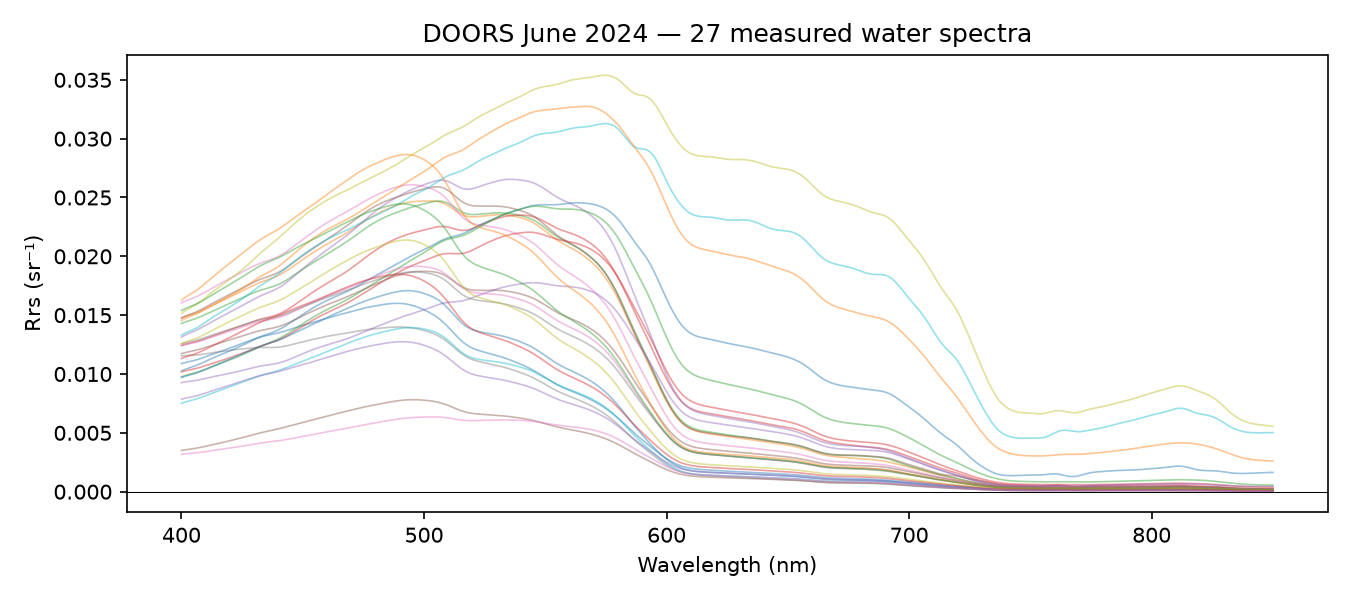

In [3]:
display(pd.read_csv(OUT/'tables/doors_optical_primary_candidates.csv'))
display(Image(filename=str(OUT/'figures/doors_spectra.png')))

,chip_id,area,longitude,latitude,date,satellite_datetime,stac_id,product_uri,folder,preview,review_status,split,training_allowed,reference_pixels,model_predictions_computed,nodata_fraction,cloud_fraction,water_fraction
0,novorossiysk-2025-06,novorossiysk,37.831,44.660,2025-06-03,2025-06-03T08:27:46.521000Z,S2B_T37TCK_20250603T082548_L2A,S2B_MSIL2A_20250603T081609_N0511_R121_T37TCK_2...,data/external/validation-bridge/blacksea_holdo...,figures/novorossiysk-2025-06.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.013000,0.987000
1,novorossiysk-2025-09,novorossiysk,37.831,44.660,2025-09-01,2025-09-01T08:27:42.898000Z,S2B_T37TDK_20250901T082111_L2A,S2B_MSIL2A_20250901T081609_N0511_R121_T37TDK_2...,data/external/validation-bridge/blacksea_holdo...,figures/novorossiysk-2025-09.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,1.000000
2,sochi-2025-06,sochi,39.700,43.550,2025-06-07,2025-06-07T08:18:12.747000Z,S2A_T37TEJ_20250607T081637_L2A,S2A_MSIL2A_20250607T081641_N0511_R078_T37TEJ_2...,data/external/validation-bridge/blacksea_holdo...,figures/sochi-2025-06.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,1.000000
3,sochi-2025-09,sochi,39.700,43.550,2025-09-01,2025-09-01T08:27:53.492000Z,S2B_T37TEJ_20250901T082111_L2A,S2B_MSIL2A_20250901T081609_N0511_R121_T37TEJ_2...,data/external/validation-bridge/blacksea_holdo...,figures/sochi-2025-09.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,1.000000
4,batumi-2025-06,batumi,41.610,41.665,2025-06-07,2025-06-07T08:18:34.628000Z,S2A_T38TKM_20250607T081637_L2A,S2A_MSIL2A_20250607T081641_N0511_R078_T38TKM_2...,data/external/validation-bridge/blacksea_holdo...,figures/batumi-2025-06.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,1.000000
5,batumi-2025-09,batumi,41.610,41.665,2025-09-15,2025-09-15T08:08:20.491000Z,S2B_T37TGG_20250915T080243_L2A,S2B_MSIL2A_20250915T075609_N0511_R035_T37TGG_2...,data/external/validation-bridge/blacksea_holdo...,figures/batumi-2025-09.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,1.000000
6,sinop-2025-06,sinop,35.125,42.065,2025-06-03,2025-06-03T08:38:50.352000Z,S2A_T36TXM_20250603T083630_L2A,S2A_MSIL2A_20250603T082751_N0511_R021_T36TXM_2...,data/external/validation-bridge/blacksea_holdo...,figures/sinop-2025-06.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.023987,0.976013
7,sinop-2025-09,sinop,35.125,42.065,2025-09-01,2025-09-01T08:38:47.747000Z,S2A_T36TXM_20250901T083630_L2A,S2A_MSIL2A_20250901T083531_N0511_R021_T36TXM_2...,data/external/validation-bridge/blacksea_holdo...,figures/sinop-2025-09.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,1.000000
8,burgas-2025-06,burgas,27.495,42.460,2025-06-03,2025-06-03T09:18:47.140000Z,S2C_T35TNH_20250603T091110_L2A,S2C_MSIL2A_20250603T090611_N0511_R050_T35TNH_2...,data/external/validation-bridge/blacksea_holdo...,figures/burgas-2025-06.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000000,0.922348
9,burgas-2025-09,burgas,27.495,42.460,2025-09-01,2025-09-01T09:18:44.852000Z,S2C_T35TNH_20250901T091155_L2A,S2C_MSIL2A_20250901T090611_N0511_R050_T35TNH_2...,data/external/validation-bridge/blacksea_holdo...,figures/burgas-2025-09.png,pending_two_reviewers,reserved_holdout,False,0,False,0.0,0.000244,0.922470


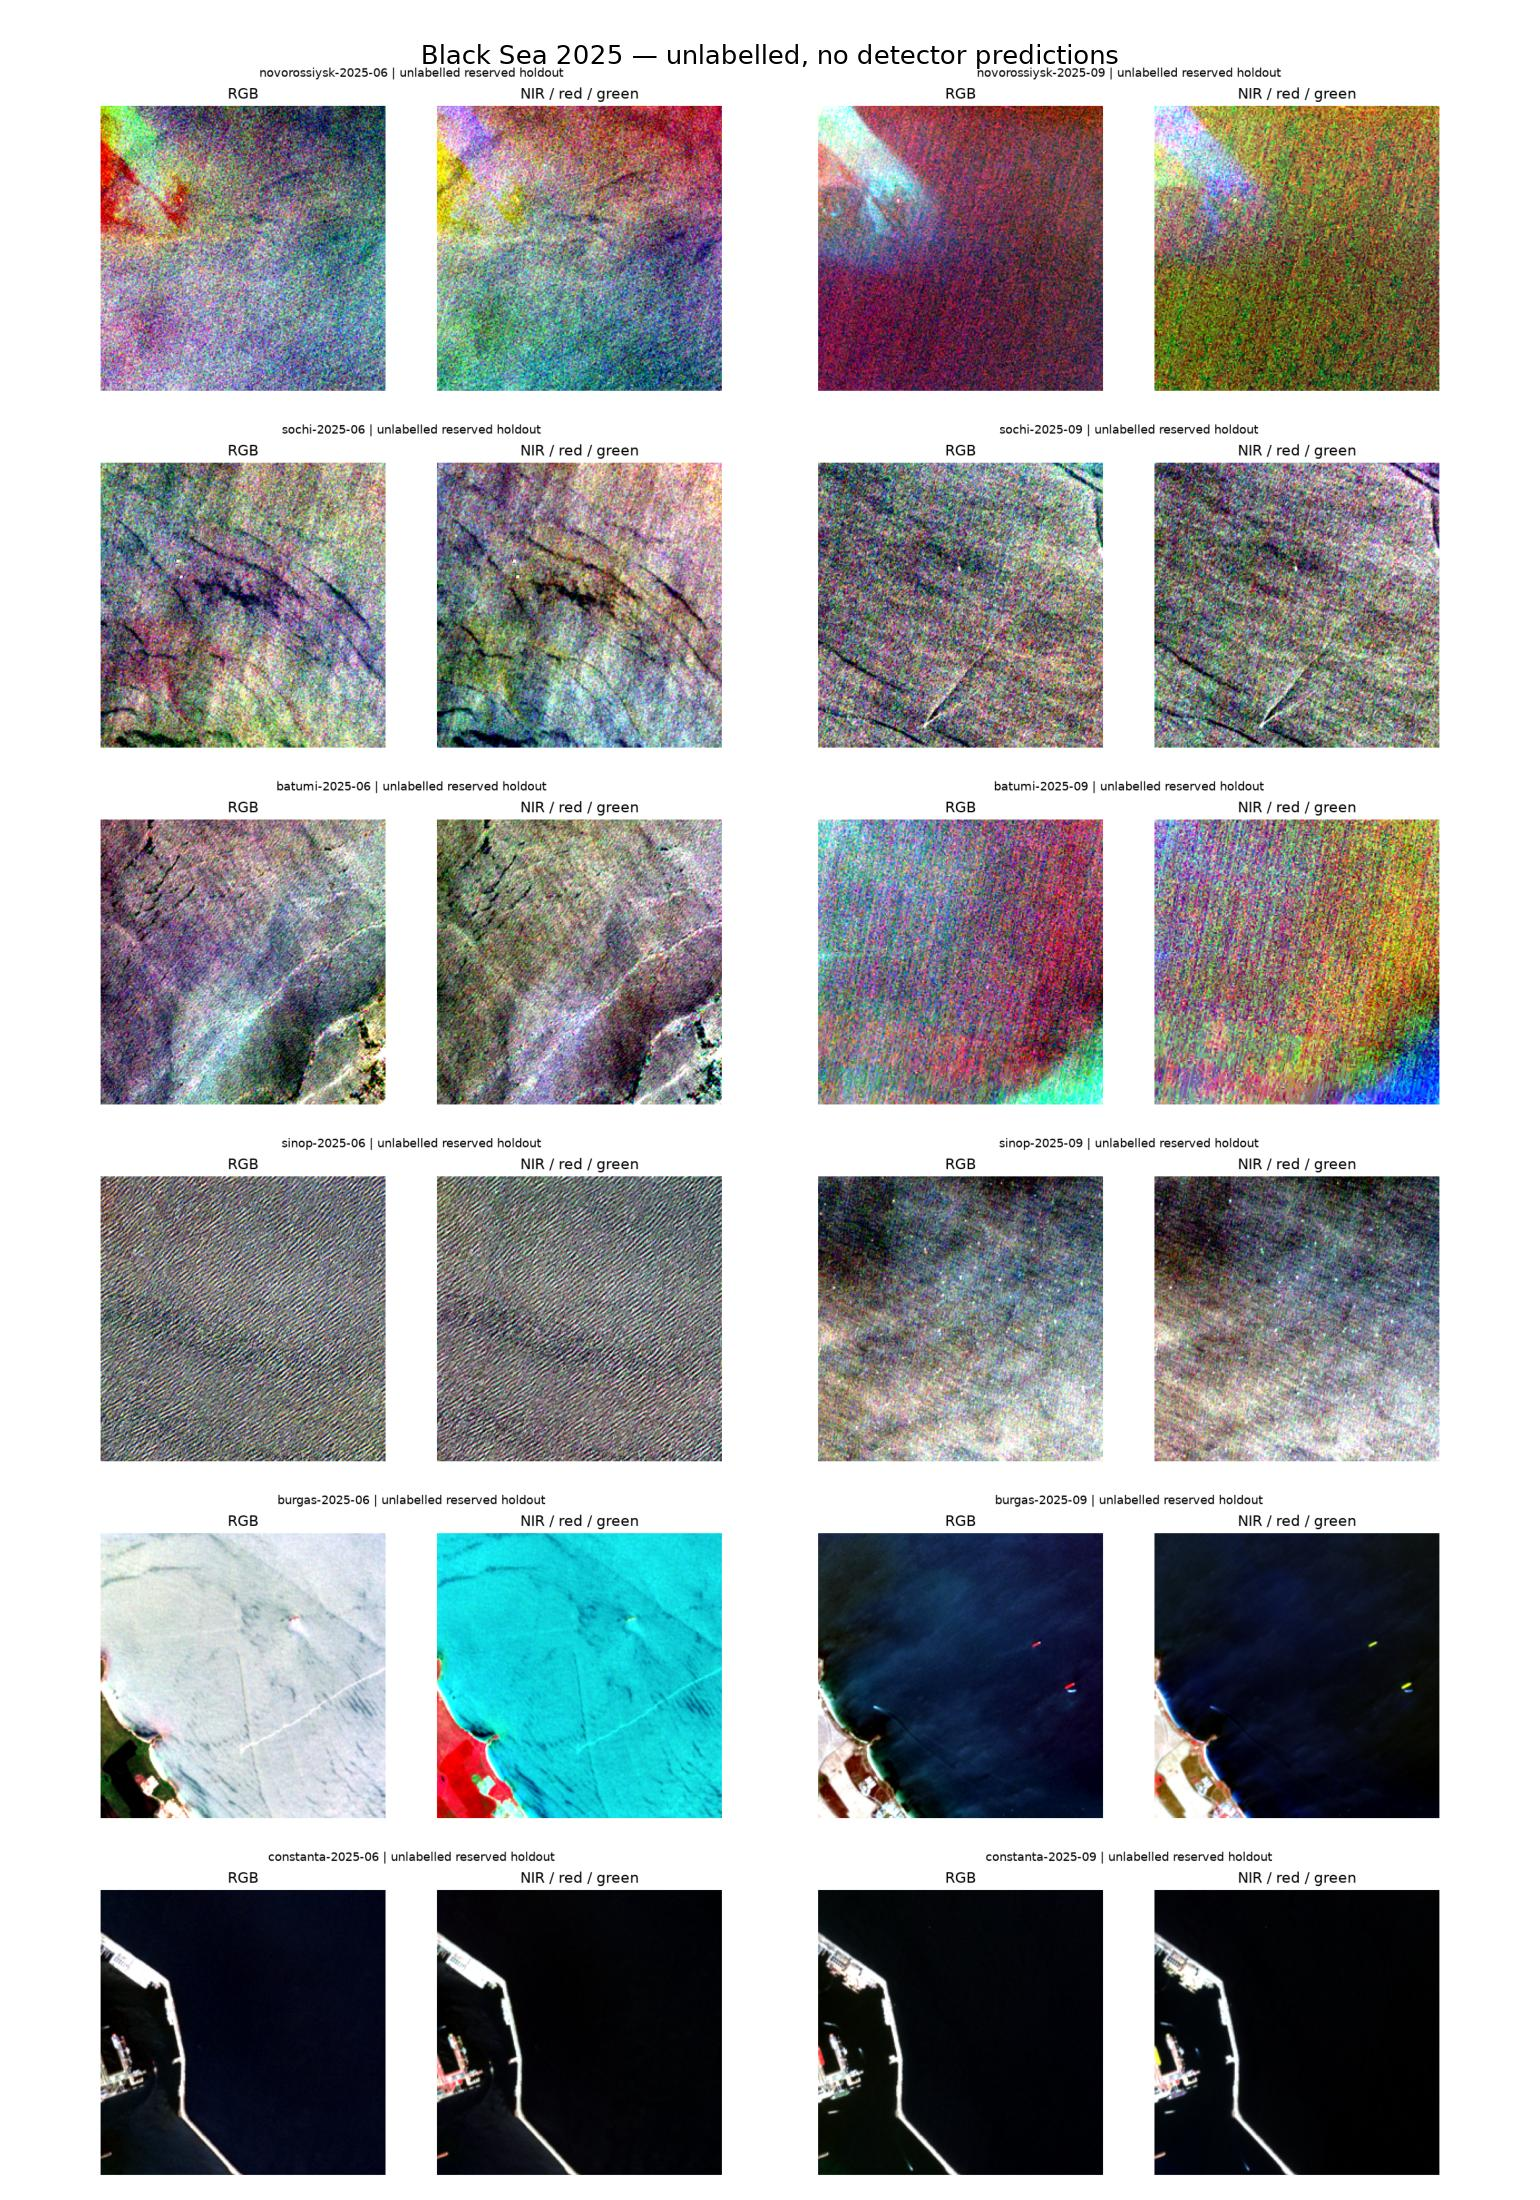

In [4]:
display(pd.read_csv(OUT/'tables/blacksea_holdout_registry.csv'))
display(Image(filename=str(OUT/'figures/blacksea_review_contact_sheet.jpg')))

In [5]:
from hashlib import sha256
import json
p=json.loads((OUT/'provenance.json').read_text())
assert sha256((ROOT/'data/case/macroplastic_marine_samples.csv').read_bytes()).hexdigest()==p['case_sha256']
assert not pd.read_csv(OUT/'tables/blacksea_holdout_registry.csv').training_allowed.any()
print('Case hash unchanged; all 12 review chips excluded from training.')

Case hash unchanged; all 12 review chips excluded from training.
